# AI vs Human Text Classification

**Dataset:** [Kaggle - AI vs Human Text](https://www.kaggle.com/datasets/shanegerami/ai-vs-human-text/data?select=AI_Human.csv)

**Problem:** Classify whether a given text was generated by AI or written by a human.

**Label:** 1 = AI-generated, 0 = Human-written

### Imports and environment preparation

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import re
from string import punctuation
from spacy.lang.en.stop_words import STOP_WORDS
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

### Data loading and preliminary analysis

In [7]:
data = pd.read_csv('AI_Human.csv', engine='python', on_bad_lines='skip')
data = data.sample(frac=1).reset_index(drop=True)
data.columns = ['text', 'label']
print(data.head())
print(data['label'].value_counts())
print(f'Dataset shape: {data.shape}')

                                                text  label
0  This paper will decride why people should join...    0.0
1  “Making Mona Lisa Smile” by Professor Thomas H...    1.0
2  Dear state senator,\n\nThe Electoral College i...    0.0
3  With the rise of digital technologies, online ...    1.0
4  Doesw the electoral college work?\n\nYes the e...    0.0
label
0.0    128993
1.0     82707
Name: count, dtype: int64
Dataset shape: (211700, 2)


### Text cleaning and processing

In [8]:
stopwords = list(STOP_WORDS)

def clean_text(text):
    text_c = text.lower()
    text_c = re.sub(r'\d', '', text_c)
    text_c = re.sub(r'<[^>]*>', '', text_c)
    emojis = re.findall(r'(?::|;|=)(?:-)?(?:\)|\(|D|P)', text_c)
    text_c = re.sub(r'[\W]+', ' ', text_c) + ' '.join(emojis).replace('-', '')
    text_c = re.sub(f'[{punctuation}]', '', text_c)
    text_c = text_c.strip()
    return text_c

lemmatizer = WordNetLemmatizer()
def tags_converter(tag_pos: str) -> str:
    if tag_pos.startswith('N'):
        return wordnet.NOUN
    elif tag_pos.startswith('V'):
        return wordnet.VERB
    elif tag_pos.startswith('J'):
        return wordnet.ADJ
    else:
        return wordnet.ADV

def tokenizer_lem(text: str) -> list:
    text = clean_text(text)
    text_split = [word for word in text.split() if word not in stopwords and len(word) > 2]
    text_pos = pos_tag(text_split)
    return [lemmatizer.lemmatize(word, tags_converter(pos)) for word, pos in text_pos]

### Feature extraction and division into sets

In [11]:
vectorizer = TfidfVectorizer(tokenizer=tokenizer_lem)
test_size = 0.3

def train_test_vectorizer(vectorizer, data, target, test_size=0.3):
    X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=test_size, stratify=target)
    X_train_vector = vectorizer.fit_transform(X_train)
    X_test_vector = vectorizer.transform(X_test)
    print(f'Training data shape after vectorization: {X_train_vector.shape}')
    return X_train_vector, X_test_vector, y_train, y_test

X_train_vector, X_test_vector, y_train, y_test = train_test_vectorizer(vectorizer, data['text'], data['label'], test_size)

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Training data shape after vectorization: (148190, 112602)


### Modeling and evaluation

MultinomialNB

MultinomialNB Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.99      0.96     38698
         1.0       0.98      0.90      0.94     24812

    accuracy                           0.95     63510
   macro avg       0.96      0.94      0.95     63510
weighted avg       0.96      0.95      0.95     63510

Confusion Matrix:
[[38216   482]
 [ 2432 22380]]


<Figure size 500x500 with 0 Axes>

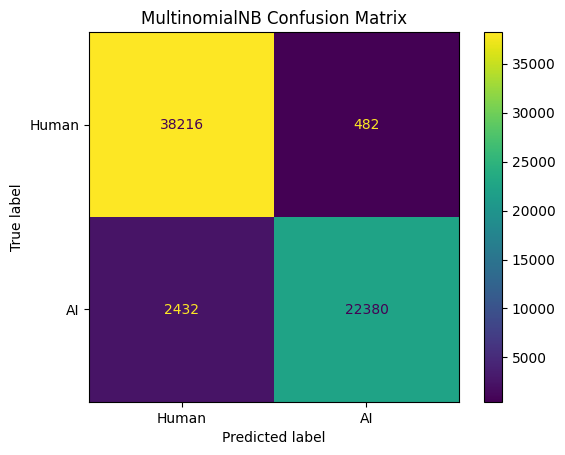

In [12]:
model_nb = MultinomialNB()
model_nb.fit(X_train_vector, y_train)
y_pred_nb = model_nb.predict(X_test_vector)
cm_nb = confusion_matrix(y_test, y_pred_nb)
print('MultinomialNB Classification Report:')
print(classification_report(y_test, y_pred_nb))
print('Confusion Matrix:')
print(cm_nb)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['Human', 'AI'])
plt.figure(figsize=(5,5))
cm_display.plot()
plt.title('MultinomialNB Confusion Matrix')
plt.show()

RandomForest + GridSearch

RandomForest Best Params: {'max_depth': 4, 'min_samples_leaf': 9}
RandomForest Classification Report:
              precision    recall  f1-score   support

         0.0       0.66      1.00      0.79     38698
         1.0       1.00      0.19      0.31     24812

    accuracy                           0.68     63510
   macro avg       0.83      0.59      0.55     63510
weighted avg       0.79      0.68      0.61     63510

Confusion Matrix:
[[38696     2]
 [20175  4637]]


<Figure size 500x500 with 0 Axes>

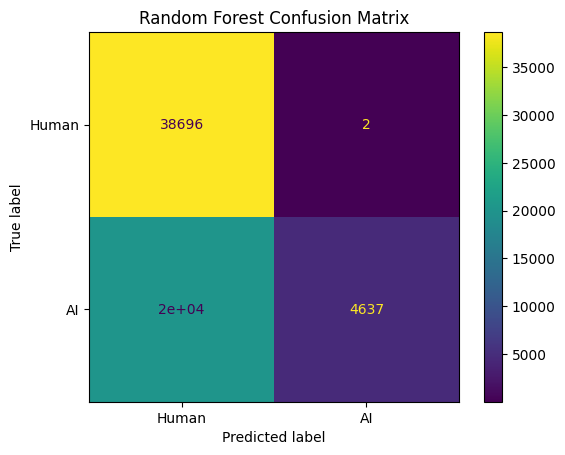

In [13]:
clf_forest = RandomForestClassifier()
params = {
    'max_depth': range(1, 5),
    'min_samples_leaf': range(5, 10)
}
grid_search_model = GridSearchCV(estimator=clf_forest, param_grid=params, scoring='accuracy', cv=3)
grid_search_model.fit(X_train_vector, y_train)
y_pred_rf = grid_search_model.predict(X_test_vector)
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f'RandomForest Best Params: {grid_search_model.best_params_}')
print('RandomForest Classification Report:')
print(classification_report(y_test, y_pred_rf))
print('Confusion Matrix:')
print(cm_rf)
cm_display_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Human', 'AI'])
plt.figure(figsize=(5,5))
cm_display_rf.plot()
plt.title('Random Forest Confusion Matrix')
plt.show()

## Summary and Conclusions

- The Multinomial Naive Bayes model achieved high accuracy, especially in identifying human-written texts.
- The Random Forest model, even with hyperparameter tuning, struggled to balance precision and recall for both classes.
- Text preprocessing (lemmatization, stopword removal, cleaning) and TF-IDF vectorization were crucial for model performance.
- Further improvements could include using more advanced NLP models (e.g., transformers) or additional feature engineering.